# Step one


In [30]:
import pandas as pd
df=pd.read_csv("/content/Customer_Master_Data.csv")
df.head()



,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [31]:
df.shape

(1000, 9)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [33]:
df1=pd.read_csv('/content/Customer_Transactions.csv')
df1.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [34]:
df1.shape

(23050, 3)

In [35]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


***ckean the data***

# Merge

In [36]:
final_df=pd.merge(df,df1,on="CustomerID",how="right")
final_df

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10771,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31,7/31/23,2383.07
1,CUST10100,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08,3/10/24,497.54
2,CUST10031,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03,2/17/25,536.78
3,CUST10987,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18,7/17/23,314.89
4,CUST10831,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30,12/15/24,2543.19
...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10710,Divit Toor,saksham79@ram.biz,Not Disclosed,73,Mumbai,Widowed,1,2024-02-18,3/11/24,931.09
23046,CUST10209,Jivin Cheema,darivana@hotmail.com,Male,56,Pune,Married,1,2024-05-09,6/19/24,2659.35
23047,CUST10570,Advika Dyal,granganathan@sathe-dhar.org,Not Disclosed,26,Pune,Single,1,2021-03-29,6/27/24,266.97
23048,CUST10075,Amira Lall,vanyabiswas@kannan.biz,Female,29,Jaipur,Married,1,2023-02-25,12/26/23,1671.73


**Convert JoinDate and TransactionDate columns to datetime.**

In [37]:
final_df['TransactionDate']=pd.to_datetime(final_df['TransactionDate'])
final_df['JoinDate']=pd.to_datetime(final_df['JoinDate'])

/tmp/ipykernel_28675/2061857950.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  final_df['TransactionDate']=pd.to_datetime(final_df['TransactionDate'])


**Ensure no nulls or bad types.**

In [38]:
print(final_df.isnull().sum())

CustomerID           0
Name                 0
Email                0
Gender               0
Age                  0
City                 0
MaritalStatus        0
NumChildren          0
JoinDate             0
TransactionDate      0
TransactionAmount    0
dtype: int64


**Validate uniqueness of CustomerID in the master dataset**


In [39]:
print(df['CustomerID'].is_unique)

True


**Ensure all transaction CustomerIDs exist in the master data**

In [40]:
print(df1['CustomerID'].isin(df['CustomerID']).all())

True


# Perform RFM Calculation

In [41]:
df_rfm = final_df.groupby('CustomerID').agg(monetary=('TransactionAmount', 'sum'),
                                        frequency=('TransactionDate', 'count'))


In [42]:
df_rfm.head()

,monetary,frequency
CustomerID,,
CUST10000,21265.49,23
CUST10001,28654.31,30
CUST10002,23884.03,24
CUST10003,24206.03,25
CUST10004,25565.30,19


In [43]:
reference_date = final_df['TransactionDate'].max() + pd.Timedelta(days=1)    #Reference Date
reference_date


Timestamp('2025-07-30 00:00:00')

In [44]:
last_transaction=final_df.groupby('CustomerID')['TransactionDate'].max()
last_transaction

,TransactionDate
CustomerID,
CUST10000,2025-07-17
CUST10001,2025-06-25
CUST10002,2025-07-12
CUST10003,2025-05-10
CUST10004,2025-07-22
...,...
CUST10995,2024-06-23
CUST10996,2025-07-15
CUST10997,2025-06-28


In [45]:
recency=(reference_date-last_transaction).dt.days     #recency

df_rfm['recency'] = recency

recency

,TransactionDate
CustomerID,
CUST10000,13
CUST10001,35
CUST10002,18
CUST10003,81
CUST10004,8
...,...
CUST10995,402
CUST10996,15
CUST10997,32


In [46]:
final_df['Recency'] = final_df['CustomerID'].map(recency)

In [47]:
final_df[['CustomerID', 'TransactionDate', 'Recency']].head()

,CustomerID,TransactionDate,Recency
0,CUST10771,2023-07-31,50
1,CUST10100,2024-03-10,11
2,CUST10031,2025-02-17,35
3,CUST10987,2023-07-17,58
4,CUST10831,2024-12-15,46


In [48]:
final_df.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount,Recency
0,CUST10771,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31,2023-07-31,2383.07,50
1,CUST10100,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08,2024-03-10,497.54,11
2,CUST10031,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03,2025-02-17,536.78,35
3,CUST10987,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18,2023-07-17,314.89,58
4,CUST10831,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30,2024-12-15,2543.19,46


# Score RFM

***R_Score, F_Score, M_Score***

In [49]:
df_rfm['R_Score'] = pd.qcut(df_rfm['recency'], q=5,labels=[5,4,3,2,1])

In [50]:
df_rfm['F_Score']=pd.qcut(df_rfm['frequency'],q=5,labels=[1,2,3,4,5])

In [51]:
df_rfm['M_Score'] =pd.qcut(df_rfm['monetary'],q=5,labels=[1,2,3,4,5])

**Concatenate the R, F, M scores into a string**

In [52]:
df_rfm['segment']=df_rfm['R_Score'].astype('str')+df_rfm['F_Score'].astype('str')+df_rfm['M_Score'].astype('str')

In [53]:
df_rfm.head()

,monetary,frequency,recency,R_Score,F_Score,M_Score,segment
CustomerID,,,,,,,
CUST10000,21265.49,23,13,4,3,2,432
CUST10001,28654.31,30,35,3,5,5,355
CUST10002,23884.03,24,18,4,3,3,433
CUST10003,24206.03,25,81,1,4,3,143
CUST10004,25565.30,19,8,5,1,4,514


***Assign Segment Labels***

In [54]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4 and r >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 3:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 3 and f <= 2:
        return 'Hibernating'
    else:
        return 'Others'

df_rfm['Customer_Segment'] = df_rfm.apply(assign_segment, axis=1)
df_rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Hibernating,273
Potential Loyalist,252
At Risk,207
Champions,127
Loyal Customer,114
Others,27


# Visualize

In [55]:
df_rfm.head()

,monetary,frequency,recency,R_Score,F_Score,M_Score,segment,Customer_Segment
CustomerID,,,,,,,,
CUST10000,21265.49,23,13,4,3,2,432,Potential Loyalist
CUST10001,28654.31,30,35,3,5,5,355,Loyal Customer
CUST10002,23884.03,24,18,4,3,3,433,Potential Loyalist
CUST10003,24206.03,25,81,1,4,3,143,At Risk
CUST10004,25565.30,19,8,5,1,4,514,Potential Loyalist


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Hibernating'),
  Text(1, 0, 'Potential Loyalist'),
  Text(2, 0, 'At Risk'),
  Text(3, 0, 'Champions'),
  Text(4, 0, 'Loyal Customer'),
  Text(5, 0, 'Others')])

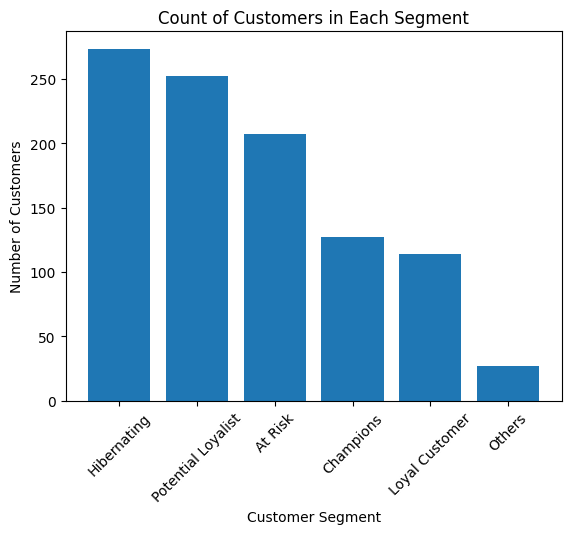

In [60]:
import matplotlib.pyplot as plt

segment_counts=df_rfm['Customer_Segment'].value_counts()
plt.bar(segment_counts.index,segment_counts.values)
plt.title('Count of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)



([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'At Risk'),
  Text(1, 0, 'Hibernating'),
  Text(2, 0, 'Potential Loyalist'),
  Text(3, 0, 'Champions'),
  Text(4, 0, 'Loyal Customer'),
  Text(5, 0, 'Others')])

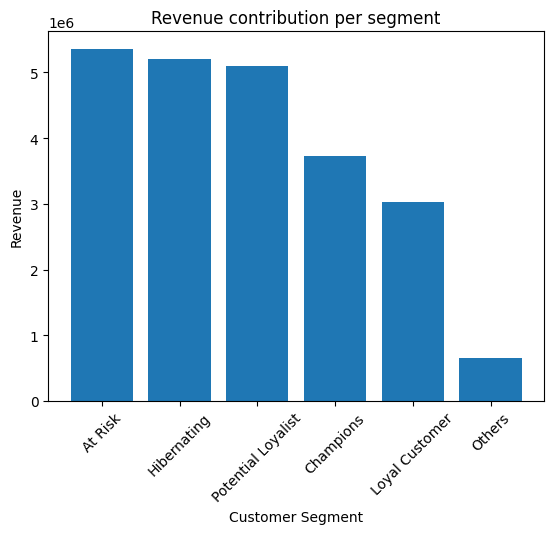

In [61]:
revenue_per_segment=df_rfm.groupby('Customer_Segment')['monetary'].sum().sort_values(ascending=False)
plt.bar(revenue_per_segment.index, revenue_per_segment.values)
plt.title('Revenue contribution per segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

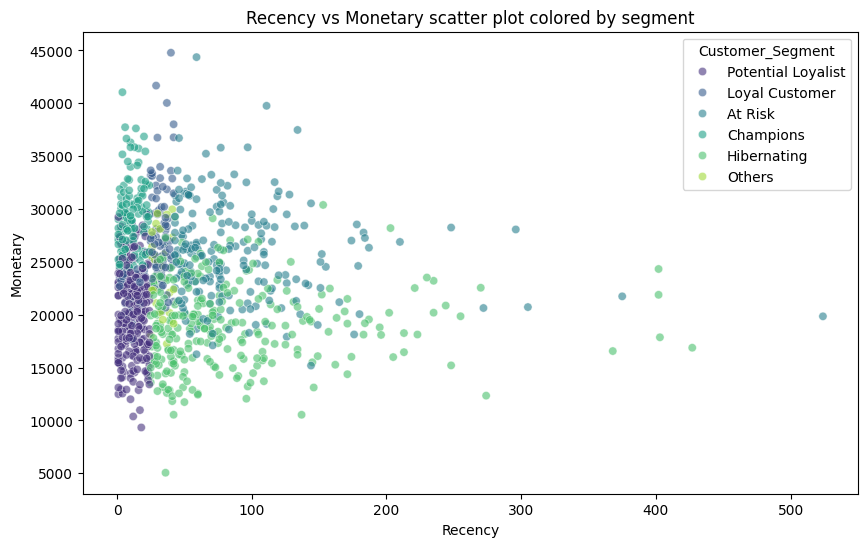

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_rfm,
    x='recency',
    y='monetary',
    hue='Customer_Segment',
    palette='viridis',
    alpha=0.6
)
plt.title('Recency vs Monetary scatter plot colored by segment')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.show()